# Neuromorphic Computing for MNIST Classification  
## Spiking Neural Network (SNN) for MNIST Classification  

This notebook presents the implementation of a biologically inspired Spiking Neural Network (SNN) for handwritten digit classification using the MNIST dataset. Unlike conventional artificial neural networks, SNNs operate using discrete spike events over time, enabling event-driven computation.

The model is built using the Norse framework (PyTorch-based), leveraging Leaky Integrate-and-Fire (LIF) neurons and surrogate gradient learning. Static images are transformed into temporal spike trains using rate-based encoding, and classification is achieved through temporal integration of output spikes.

This work explores the feasibility of neuromorphic approaches for standard vision tasks and highlight potential relevance for neuromorphic hardware platforms.

## Environment Setup  

The following libraries are used for implementing and training the spiking neural network:

- **PyTorch** for tensor operations and optimization  
- **Norse** for spiking neuron models and simulation  
- **Torchvision** for dataset loading and preprocessing  
- **NumPy** for numerical operations  
- **Matplotlib** for visualization  

To ensure reproducibility, random seeds are fixed across libraries.

In [16]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import norse.torch as norse
from norse.torch.functional.lif import LIFState
from norse.torch import LIFCell

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Dataset: MNIST  

The MNIST dataset consists of 70,000 grayscale images of handwritten digits (0–9), each of size 28×28 pixels.

- Training samples: 60,000  
- Test samples: 10,000  
- Input format: grayscale images normalized to [0,1]  

This dataset serves as a standard benchmark for evaluating classification models, including neuromorphic systems.

In [18]:
# Transform: convert to tensor and normalize to [0,1]
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


## Spike Encoding: Rate Coding  

Since SNNs process temporal spike data rather than static inputs, images must be converted into spike trains.

In this implementation, **rate-based encoding** is used:
- Pixel intensities are interpreted as firing probabilities  
- Higher intensity → higher spike probability  
- Spike trains are generated over multiple discrete time steps  

This approach preserves spatial information while introducing temporal dynamics required for spiking computation.

In [19]:
def rate_encode(images, time_steps=25):
    """
    Convert batch of images to spike trains using rate coding
    images: [batch, 1, 28, 28]
    returns: [time_steps, batch, 28*28]
    """
    batch_size = images.size(0)
    images_flat = images.view(batch_size, -1)
    # Normalize to [0,1]
    images_flat = images_flat.clamp(0, 1)
    
    # Generate spikes
    spikes = torch.rand(time_steps, batch_size, images_flat.size(1), device=images.device)
    spikes = (spikes < images_flat.unsqueeze(0)).float()
    return spikes

## Model Architecture: Spiking Neural Network  

The network consists of two fully connected layers interleaved with Leaky Integrate-and-Fire (LIF) neurons.

### Key Components:
- **Input Layer:** Flattened spike-encoded images (28×28 → 784)  
- **Hidden Layer:** Fully connected + LIF neurons  
- **Output Layer:** Fully connected + LIF neurons  

### Temporal Processing:
- Inputs are processed sequentially over time steps  
- Membrane potentials are updated dynamically  
- Output spikes are accumulated across time for classification  

### Learning Mechanism:
- Surrogate gradient descent is used to approximate gradients through non-differentiable spike functions  

In [20]:
class SNN_MNIST(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=128, output_size=10):
        super(SNN_MNIST, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lif1 = LIFCell()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.lif2 = LIFCell()
    
    def forward(self, x):
        # x: [time_steps, batch, input_size]
        time_steps, batch_size, _ = x.size()
        
        mem1 = self.lif1.initial_state(torch.zeros(batch_size, self.fc1.out_features, device=x.device))
        mem2 = self.lif2.initial_state(torch.zeros(batch_size, self.fc2.out_features, device=x.device))
        
        out_spikes = torch.zeros(batch_size, self.fc2.out_features, device=x.device)
    
        for t in range(time_steps):
            z1 = self.fc1(x[t])
            spk1, mem1 = self.lif1(z1, mem1)
            
            z2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(z2, mem2)
            
            out_spikes += spk2  # temporal integration

        return out_spikes


In [21]:
model = SNN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Training Strategy  

The model is trained using supervised learning with the following configuration:

- **Loss Function:** Cross-Entropy Loss  
- **Optimizer:** Adam  
- **Learning Rate:** 1e-3  
- **Epochs:** 10  
- **Time Steps:** 25  

During training:
- Each input is converted into a spike train  
- The network processes temporal data sequentially  
- Output spikes are integrated over time  
- Classification is performed based on accumulated activity  

This setup enables learning in a temporally dynamic spiking environment.

In [22]:
num_epochs = 10
time_steps = 25

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        spikes_in = rate_encode(images, time_steps)
        
        optimizer.zero_grad()
        outputs = model(spikes_in)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")


Epoch 1/10 - Loss: 0.3933, Accuracy: 88.28%
Epoch 2/10 - Loss: 0.2033, Accuracy: 93.83%
Epoch 3/10 - Loss: 0.1477, Accuracy: 95.50%
Epoch 4/10 - Loss: 0.1170, Accuracy: 96.39%
Epoch 5/10 - Loss: 0.0975, Accuracy: 96.97%
Epoch 6/10 - Loss: 0.0828, Accuracy: 97.35%
Epoch 7/10 - Loss: 0.0757, Accuracy: 97.54%
Epoch 8/10 - Loss: 0.0642, Accuracy: 97.94%
Epoch 9/10 - Loss: 0.0581, Accuracy: 98.06%
Epoch 10/10 - Loss: 0.0541, Accuracy: 98.18%


## Model Evaluation  

After training, the model is evaluated on the test dataset.

- Spike encoding is applied similarly to test data  
- No gradient updates are performed  
- Predictions are obtained from accumulated output spikes  

The final test accuracy provides a measure of the model's generalization capability.

In [23]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        spikes_in = rate_encode(images, time_steps)
        outputs = model(spikes_in)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100.0 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 96.88%


## Spike Train Visualization  

To better understand the temporal dynamics of the encoding process, spike trains are visualized for a subset of input images.

Each row corresponds to a sample, and each column represents activity at a given time step. This visualization highlights how static pixel intensities are transformed into stochastic spike patterns over time.

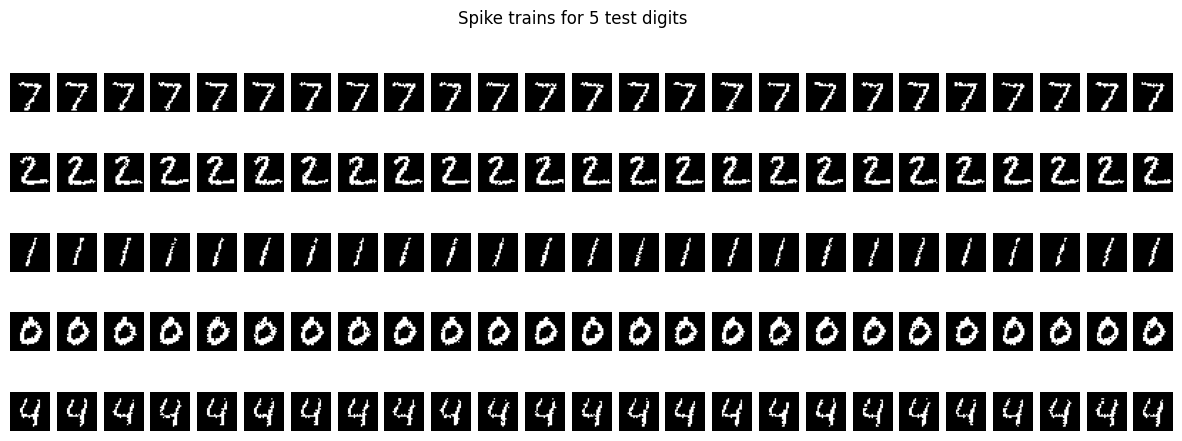

In [24]:
# Pick one batch
images, labels = next(iter(test_loader))
images = images.to(device)
spikes_in = rate_encode(images[:5], time_steps)

fig, axes = plt.subplots(5, time_steps, figsize=(15,5))

for i in range(5):
    for t in range(time_steps):
        axes[i, t].imshow(spikes_in[t, i].view(28,28).cpu(), cmap='gray')
        axes[i, t].axis('off')
plt.suptitle("Spike trains for 5 test digits")
plt.show()


## Results & Discussion  

The spiking neural network achieves high classification accuracy on the MNIST dataset within a limited number of training epochs.

### Key Observations:
- The model reaches ~97% test accuracy, demonstrating strong performance for a simple spiking architecture  
- Temporal spike integration effectively captures input information  
- Rate-based encoding provides a simple yet effective bridge between static images and spiking computation  

### Implications:
- SNNs can perform standard vision tasks with high efficiency  
- The event-driven nature of computation makes them suitable for low-power neuromorphic hardware  
- This approach can be extended to more complex datasets and architectures  

Overall, this study highlights the potential of spiking neural networks as a viable alternative to traditional deep learning models.